In this assignment, you need to analyze a large set of customer reviews and come up with recommendations to the Singapore Airlines CEO to improve customer satisfaction.

The notebook serves as a starting point for your analysis.

At the end of the assignment, you should deliver a five-slide "elevator pitch" to the CEO summarizing your findings and recommendations, backing up your claims with analyses.

# Topic Modeling with Transformers

We have seen that transformers are a powerful tool to build encodings of text that capture context, order of words, etc... Typically, one uses a pre-trained transformer to produce the encodings, and then feeds these to their own model (e.g. a neural network) to solve their particular NLP task, like sentiment analysis or sequence labeling.

In this notebook, you will solve another NLP task called topic analysis (more on that later). You will use the BERTopic package for this task, which is built on top of HuggingFace transformers.

With BERTopic, you will analyze a dataset of Singapore Airlines customer reviews to gain insight into how to improve the customer experience.

You can find an expansive description of the dataset here
https://www.kaggle.com/datasets/kanchana1990/singapore-airlines-reviews


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the data

We load the data and output some summary of the data columns.

In [2]:
df = pd.read_csv('https://www.dropbox.com/scl/fi/ekrltx48nq8ll7txpmkcg/singapore_airlines_reviews.csv?rlkey=lj0uqi5vpaaploqxg50yqbrj1&st=mindhem4&dl=1')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   published_date      10000 non-null  object
 1   published_platform  10000 non-null  object
 2   rating              10000 non-null  int64 
 3   type                10000 non-null  object
 4   text                10000 non-null  object
 5   title               9999 non-null   object
 6   helpful_votes       10000 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 547.0+ KB


In [4]:
df.head()

,published_date,published_platform,rating,type,text,title,helpful_votes
0,2024-03-12T14:41:14-04:00,Desktop,3,review,We used this airline to go from Singapore to L...,Ok,0
1,2024-03-11T19:39:13-04:00,Desktop,5,review,The service on Singapore Airlines Suites Class...,The service in Suites Class makes one feel lik...,0
2,2024-03-11T12:20:23-04:00,Desktop,1,review,"Booked, paid and received email confirmation f...",Don’t give them your money,0
3,2024-03-11T07:12:27-04:00,Desktop,5,review,"Best airline in the world, seats, food, servic...",Best Airline in the World,0
4,2024-03-10T05:34:18-04:00,Desktop,2,review,Premium Economy Seating on Singapore Airlines ...,Premium Economy Seating on Singapore Airlines ...,0


In [5]:
## If you want to see more text from the review, you can increase the display.max_colwidth

#pd.set_option('display.max_colwidth', 50)

## Quick summary statistics and visualizations

Let's look at some summary statistics for our dataset. For example, are there any interesting trends, or relationships between the length of reviews, presence of specific words, and ratings.

In [6]:
# Step 1: Calculate the length of each review
df['review_length'] = df['text'].apply(len)

# For simplicity, let's consider "excellent" for positive and "terrible" for negative sentiments
df['contains_excellent'] = df['text'].str.contains('excellent', case=False).astype(int)
df['contains_terrible'] = df['text'].str.contains('terrible', case=False).astype(int)

# Preparing data for visualization
# We'll aggregate data to see if there's a visible trend between the length of reviews, presence of specific words, and ratings
aggregated_data = df.groupby('rating').agg({
    'review_length': 'mean',
    'contains_excellent': 'mean',
    'contains_terrible': 'mean'
}).reset_index()

aggregated_data

,rating,review_length,contains_excellent,contains_terrible
0,1,920.468307,0.021760,0.096500
1,2,871.423573,0.053407,0.071823
2,3,737.867195,0.080278,0.042616
3,4,526.661922,0.149466,0.006101
4,5,431.168326,0.222345,0.002028


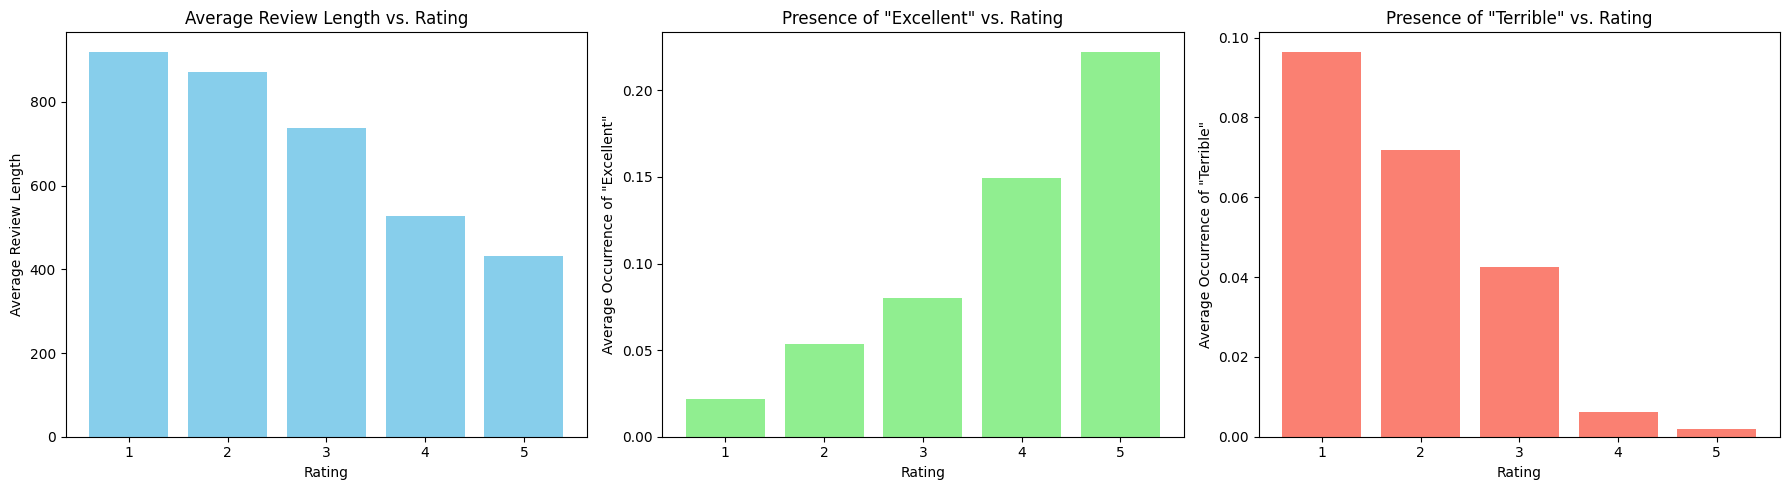

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Review length vs. rating
axes[0].bar(aggregated_data['rating'], aggregated_data['review_length'], color='skyblue')
axes[0].set_title('Average Review Length vs. Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Average Review Length')

# Presence of "excellent" vs. rating
axes[1].bar(aggregated_data['rating'], aggregated_data['contains_excellent'], color='lightgreen')
axes[1].set_title('Presence of "Excellent" vs. Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Average Occurrence of "Excellent"')

# Presence of "terrible" vs. rating
axes[2].bar(aggregated_data['rating'], aggregated_data['contains_terrible'], color='salmon')
axes[2].set_title('Presence of "Terrible" vs. Rating')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Average Occurrence of "Terrible"')

plt.tight_layout()
plt.show()

We next aggregate the data by year, and plot how the ratings have changed over time.


In [8]:
df['published_date'] = pd.to_datetime(df['published_date'], format='ISO8601', utc=True)
df['year'] = df['published_date'].dt.year
df.head()

,published_date,published_platform,rating,type,text,title,helpful_votes,review_length,contains_excellent,contains_terrible,year
0,2024-03-12 18:41:14+00:00,Desktop,3,review,We used this airline to go from Singapore to L...,Ok,0,1352,0,0,2024
1,2024-03-11 23:39:13+00:00,Desktop,5,review,The service on Singapore Airlines Suites Class...,The service in Suites Class makes one feel lik...,0,4666,1,0,2024
2,2024-03-11 16:20:23+00:00,Desktop,1,review,"Booked, paid and received email confirmation f...",Don’t give them your money,0,420,0,0,2024
3,2024-03-11 11:12:27+00:00,Desktop,5,review,"Best airline in the world, seats, food, servic...",Best Airline in the World,0,144,0,0,2024
4,2024-03-10 09:34:18+00:00,Desktop,2,review,Premium Economy Seating on Singapore Airlines ...,Premium Economy Seating on Singapore Airlines ...,0,582,0,0,2024


In [9]:
aggregated_data = df.groupby('year').agg({
    'rating': 'mean',
}).reset_index()

aggregated_data

,year,rating
0,2018,4.319710
1,2019,4.246012
2,2020,4.046103
3,2021,2.435294
4,2022,2.181159
5,2023,2.684112
6,2024,2.333333


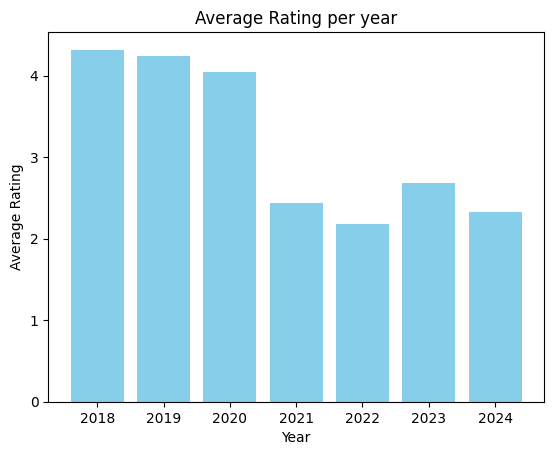

In [10]:
plt.bar(aggregated_data['year'], aggregated_data['rating'], color='skyblue')
plt.title('Average Rating per year')
plt.xlabel('Year')
plt.ylabel('Average Rating')

plt.show()

# Ooops...

There seems to be a meaningful drop in ratings from 2021 onwards. Imagine you report to the Singapore Airlines CEO and you need to formulate a plan of action to improve this situation. It would be nice to see what has gone wrong.

Fortunately, you have the review data that may contain some information about what could be going wrong. This is where topic modeling comes in to help. In short, [topic modeling is a technique that allows you to extract "topics" that occur in a large collection of text](https://en.wikipedia.org/wiki/Topic_model). In this notebook, you will use BERTopic, a topic modeling package built on top of HuggingFace transformers.

Your task is to use BERTopic to explain the negative shift in ratings, and then present your findings as a one-slide pitch that you will present in class.

First, load up BERTopic and familiarize yourselves with its functionality.

# Topic analysis using BERTopic

In this assignment, you will not need to build a transformer per se. What you will do is use an ML package that uses a pre-trained transformer to solve a specific NLP task. In this case, that is topic modeling.

First, if running on Colab (which is highly recommended at least for creating your topic model), you will need to install the package:

In [11]:
#!pip install bertopic

In [12]:
from bertopic import BERTopic

In [13]:
topic_model = BERTopic(embedding_model = 'all-MiniLM-L6-v2')

It can take a long time to train the topic model on the entire dataset. To reduce the load, we slice the dataset by year 2019 and run training.

Also, note that so far we are not making any specifications about the training process. The [documentation for BERTopic](https://maartengr.github.io/BERTopic/index.html) gives lots of information on how to tweak the fitting behavior (and how to access different [embeddings](https://maartengr.github.io/BERTopic/getting_started/embeddings/embeddings.html), etc.). It also pays to take a look at the [best practices](https://maartengr.github.io/BERTopic/getting_started/best_practices/best_practices.html).

In [14]:
df_slice = df[(df['year'] == 2019)]

In [15]:
topics, probs = topic_model.fit_transform(df_slice['text'])

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Ok, let's see what this topic_model has to say. The following command returns the list of topics ordered by frequency. You can also see the most relevant words for the topic, and the most relevant reviews.

Note: topic -1 is a dummy topic and should generally be ignored. It aggregates all the outliers and reviews that couldn't be clustered into a topic.

In [16]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2619,-1_the_and_to_was,"[the, and, to, was, of, flight, in, on, singap...",[I've flown with this airline for ten years on...
1,0,270,0_singapore_to_from_and,"[singapore, to, from, and, flight, the, in, on...",[We had a really good flight from Melbourne to...
2,1,261,1_airlines_singapore_is_are,"[airlines, singapore, is, are, airline, best, ...",[We have flown Singapore Airlines for years an...
3,2,136,2_economy_premium_the_not,"[economy, premium, the, not, singapore, to, we...",[We paid for Premium Economy on our recent tri...
4,3,116,3_airline_best_service_this,"[airline, best, service, this, is, the, great,...",[We have travelled before with this airline an...
5,4,112,4_class_business_singapore_is,"[class, business, singapore, is, airlines, the...",[My first experience in first class with Singa...
6,5,108,5_sq_is_the_and,"[sq, is, the, and, to, in, always, with, my, of]","[Always good to fly with SQ. Service, food, se..."
7,6,91,6_seats_seat_was_were,"[seats, seat, was, were, comfortable, and, the...",[Plane itself was clean and tidy. Staff were ...
8,7,87,7_economy_premium_seats_extra,"[economy, premium, seats, extra, more, the, wo...",[I cannot recommend Premium Economy enough - p...
9,8,81,8_a380_the_was_on,"[a380, the, was, on, very, you, and, seats, bu...",[I have made this trip a few times on differen...


You can also obtain information on a specific topic. For example below you can look into topic 2 and get the top words for that topic. The numbers on the right quantify the importance of those words to the topic.

In [17]:
topic_model.get_topic(2)

[('economy', 0.04235687188858876),
 ('premium', 0.03763789830075053),
 ('the', 0.014930837085738299),
 ('not', 0.014024357903631206),
 ('singapore', 0.013676363131473844),
 ('to', 0.013626777765730085),
 ('we', 0.013264646882733596),
 ('and', 0.013032030464260528),
 ('for', 0.012554730721589406),
 ('of', 0.01224230066802906)]

Here, you can get representative reviews for a topic.

In [18]:
topic_model.get_representative_docs(2)

['We paid for Premium Economy on our recent trip to and from Europe.  We had done the same two years ago with Singapore Airlines and had found the extra we had paid was worthwhile as we fly direct to and from Europe.\nThis time however we think we just wasted our money.  There was very little benefit.  Yes the seats are slightly wider.  On our return flight this time there were eight seats across the plane in Premium Economy and nine in Economy.  I guess there is marginally more legroom but as we were seated in the four seats in the middle you don’t really notice it.  The extra leg rest that comes out from the bottom of the seat is completely useless and uncomfortable.\nThere used to be a welcome drink but no longer. Premium Economy certainly on Qantas gets a real glass for your drink not a disposable plastic one.\nThe food this time was the same as Economy and pretty dreadful I have to say.\nThere is no extra service that we noted although the cabin staff are pleasant but equally plea

You can also visualize topic relationships in 2d space.

In [19]:
topic_model.visualize_topics()

Or visualize topic word scores.

In [20]:
topic_model.visualize_barchart()

Finally, it is often handy to visualize the term rank, to see clearly which topics have a particular focus on just a few words.

In [21]:
topic_model.visualize_term_rank()


Let's organize the topics and reviews in a dataframe.

In [22]:
topic_df = pd.DataFrame({"topic": topics, "document": df_slice['text']})
topic_df

,topic,document
2179,53,I traveled with my family to Singapore for C...
2180,3,"The plane ride was excellent, new plane what a..."
2181,-1,Lots of good food and amenities. Their menu ev...
2182,14,Our night flight back from Narita was about 7 ...
2183,-1,Singapore Airport and airlines rank amongst th...
...,...,...
7377,-1,This flight was the day after we arrived in Si...
7378,-1,This was the first time we have flown with Sin...
7379,-1,The meal was really good but for all other ele...
7380,34,The flight from Delhi to Bali via Singaore on...


# Your Task

Use BERTopic (as well as additional tools you deem useful) to arrive at a set of explanations for the drop in ratings, and a corresponding set of recommendations to the CEO.

You can consult any resources to find out about more of the functionality of BERTopic.

As an example of something you could do, try to slice the data, say by year. What happens when rerun the topic model on the data slice? Is there any menaingful information that comes out?

In general, this is an open-ended exercise. Be creative!

# Deliverables

See the assignment descriptions for a full overview of the deliverables.

# Your analysis

## 1. Import Library

In [23]:
# Write your code here
import pandas as pd
import numpy as np
from umap import UMAP 
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer

from sklearn.feature_extraction import text

import random
import numpy as np

random.seed(3845)
np.random.seed(3845)

## 2. Data pre-processing

Visualise the data between different years

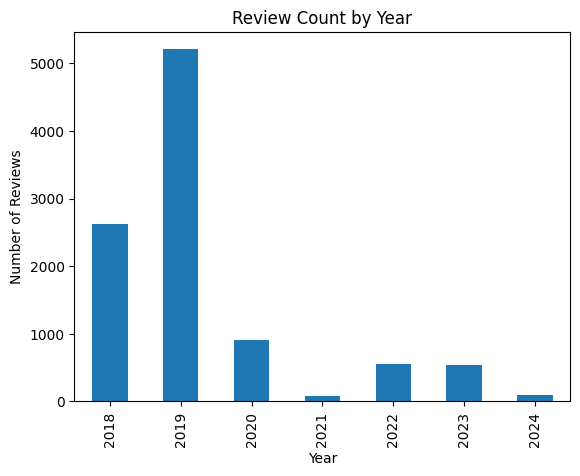

In [24]:
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Review Count by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

Split the data into years with high ratings and years with low ratings.

In [25]:
df_slice_before = df[df['year'].isin([2018, 2019, 2020])]
df_slice_after = df[df['year'].isin([2021, 2022, 2023, 2024])]

## 3. Method

### 3.1 Find the Best Parameters for BERTopic

To identify the optimal parameter settings for topic modeling using BERTopic, we implemented a full grid search over a range of hyperparameters for the UMAP and HDBSCAN models. This allows us to systematically evaluate how different configurations affect the quality and structure of the resulting topics.  

We search over combinations of the following hyperparameters:
- n_neighbors (UMAP)
- n_components (UMAP)
- min_dist (UMAP)
- min_cluster_size (HDBSCAN)
- min_samples (HDBSCAN)  

For each parameter combination, the code constructs a BERTopic pipeline with the specified UMAP and HDBSCAN settings, along with a consistent embedding model (all-MiniLM-L6-v2), topic vectorizer, and representation model (KeyBERTInspired). It then fits the model to the input documents and records key metrics including:
- Number of discovered topics (excluding noise)
- Number of noise documents (i.e., documents not assigned to any topic)
- Average number of documents per topic  
- Coherence score

These results are stored in a DataFrame, allowing for easy comparison across configurations. The final output is a summary table of all tested parameter sets, which can be sorted and analyzed to select the most effective topic modeling setup.

In [26]:

from itertools import product
from collections import Counter
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def full_parameter_grid_search(documents, param_grid, stopwords=None):

    results = []

    all_combinations = list(product(
        param_grid["n_neighbors"],
        param_grid["n_components"],
        param_grid["min_dist"],
        param_grid["min_cluster_size"],
        param_grid["min_samples"]
    ))

    for n_neighbors, n_components, min_dist, min_cluster_size, min_samples in all_combinations:
        print(f"Try: nn={n_neighbors}, comp={n_components}, dist={min_dist}, mcs={min_cluster_size}, ms={min_samples}")

        ##### BERTopic setup
        # Step 1 - Extract embeddings
        embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
        # Step 2
        umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=min_dist, metric="cosine", random_state=3845)
        # Step 3
        hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric="euclidean", prediction_data=True)    
        # Step 4 - Tokenize topics
        vectorizer_model = CountVectorizer(stop_words=stopwords, ngram_range=(1, 2))
        #vectorizer_model = CountVectorizer(stop_words="english")
        # Step 5 - Create topic representation
        ctfidf_model = ClassTfidfTransformer()
        # Step 6 - (Optional Fine-tune topic representations with
        # a `bertopic.representation` model
        representation_model = KeyBERTInspired()
        
        # All steps together
        topic_model = BERTopic(
            embedding_model=embedding_model,          # Step 1 - Extract embeddings
            umap_model=umap_model,                    # Step 2 - Reduce dimensionality
            hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
            vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
            ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
            representation_model=representation_model # Step 6 - (Optional) Fine-tune topic representations
        )
        ##### Fit BERTopic model
        try:
            topics, _ = topic_model.fit_transform(documents)
        except Exception as e:
            print(f"Error: {e}")
            continue
        
        ##### Calculate topics numbers, noise number
        topic_counts = Counter(topics)
        n_topics = len([t for t in topic_counts if t != -1])
        n_noise = topic_counts.get(-1, 0)
        total_points = len(documents)
        avg_per_topic = round(total_points / max(n_topics, 1), 2)
        
        ##### Calculate Coherence score
        
        # Take the top n words for each topic
        # Get topic words from BERTopic model safely
        top_words = []
        for i in topic_model.get_topics().keys():
            if i == -1:
                continue  # skip noise topic
            topic = topic_model.get_topic(i)
            if topic is None:
                continue
            words = [word for word, _ in topic if isinstance(word, str)]
            if len(words) == 0:
                continue
            top_words.append(words)
        
        # Build gensim corpus and dictionary
        tokenized_docs = [doc.split() for doc in documents]  # or use your tokenizer
        dictionary = Dictionary(tokenized_docs)
        corpus = [dictionary.doc2bow(text) for text in tokenized_docs]
        # Calculate Coherence
        coherence_model = CoherenceModel(topics=top_words, texts=tokenized_docs, dictionary=dictionary, coherence='c_v')
        coherence_score = coherence_model.get_coherence()
        
        print("DEBUG: coherence_score =", coherence_score)
        
        ##### Save result in pandas dataframe
        results.append({
            "n_neighbors": n_neighbors,
            "n_components": n_components,
            "min_dist": min_dist,
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_topics": n_topics,
            "n_noise": n_noise,
            "avg_docs_per_topic": avg_per_topic,
            "coherence_score": coherence_score
        })

    return pd.DataFrame(results)

Set the stopwords  
Use default stopwords (ENGLISH_STOP_WORDS) and manually add some stopwords

In [27]:
# Use default stopwords (ENGLISH_STOP_WORDS) and manually add some stopwords
default_stopwords = text.ENGLISH_STOP_WORDS
custom_words = ["singapore", "airline", "airlines", "flight", "flights", "flying", "airplane", "aircraft", "planes", "plane",
                "airport", "airways", "flown", "travel", "flew", "fly", "travelling", "trip", "journey", "thai", "sydney", "changi",
                "sq", "sia", "iata", "emirates",
                "qantas", "singaporeair", "sa",
                "perth", "melbourne", "heathrow", "brisbane", "canberra", "auckland", 
                "jakarta", "thailand", "vietnam", "bali", "kuala", "asia", "seoul", "australia", "adelaide", "hong", "hong kong", 
                "new zealand", "wellington", "air nz", "nz", "london", "manchester", "bangkok", "travelled",
                "a380", "a350", "a330", "airbus", "passengers"]
combined_stopwords = list(default_stopwords.union(custom_words))

Run the test

In [28]:
# Set the combination of parameters you want to measure
param_grid = {
    "n_neighbors": [10, 15],
    "n_components": [5, 10],
    "min_dist": [0.05, 0.1],
    "min_cluster_size": [10, 20, 30],
    "min_samples": [5, 10]
}
# Perform the test
df_results = full_parameter_grid_search(df_slice_after["text"], param_grid, combined_stopwords)

Try: nn=10, comp=5, dist=0.05, mcs=10, ms=5
DEBUG: coherence_score = 0.494529068330197
Try: nn=10, comp=5, dist=0.05, mcs=10, ms=10
DEBUG: coherence_score = 0.554081140503227
Try: nn=10, comp=5, dist=0.05, mcs=20, ms=5
DEBUG: coherence_score = 0.5192989968638468
Try: nn=10, comp=5, dist=0.05, mcs=20, ms=10
DEBUG: coherence_score = 0.47911027693473757
Try: nn=10, comp=5, dist=0.05, mcs=30, ms=5
DEBUG: coherence_score = 0.5192989968638468
Try: nn=10, comp=5, dist=0.05, mcs=30, ms=10
DEBUG: coherence_score = 0.5211989633910185
Try: nn=10, comp=5, dist=0.1, mcs=10, ms=5
DEBUG: coherence_score = 0.5542008719511023
Try: nn=10, comp=5, dist=0.1, mcs=10, ms=10
DEBUG: coherence_score = 0.5220932682539305
Try: nn=10, comp=5, dist=0.1, mcs=20, ms=5
DEBUG: coherence_score = 0.5272936005885587
Try: nn=10, comp=5, dist=0.1, mcs=20, ms=10
DEBUG: coherence_score = 0.5289559034679149
Try: nn=10, comp=5, dist=0.1, mcs=30, ms=5
DEBUG: coherence_score = 0.5668017974384891
Try: nn=10, comp=5, dist=0.1, mcs

Now we can see that from the result dataframe. Group 26 (n_neighbors=15, n_components=5, min_dist=0.05, min_cluster_size=20, min_samples=5) provided the highest coherence_score (0.60106) with 13 topics. This configuration ensures clear differentiation among topics without reducing the document classification to too few categories. Meanwhile, each topic averages about 97 documents, which reflects good internal clustering, despite having 438 noise documents—a common occurrence when the content of noise documents is indeed disorganized.

Therefore, if the primary focus is on topic coherence and differentiation, Group 26 performs the best among these experimental results.

In [29]:
df_results

,n_neighbors,n_components,min_dist,min_cluster_size,min_samples,n_topics,n_noise,avg_docs_per_topic,coherence_score
0,10,5,0.05,10,5,28,536,45.29,0.494529
1,10,5,0.05,10,10,19,584,66.74,0.554081
2,10,5,0.05,20,5,5,182,253.60,0.519299
3,10,5,0.05,20,10,5,267,253.60,0.479110
4,10,5,0.05,30,5,5,182,253.60,0.519299
5,10,5,0.05,30,10,4,197,317.00,0.521199
6,10,5,0.10,10,5,24,586,52.83,0.554201
7,10,5,0.10,10,10,17,676,74.59,0.522093
8,10,5,0.10,20,5,5,301,253.60,0.527294
9,10,5,0.10,20,10,5,327,253.60,0.528956


### 3.2 Year 2021, 2022, 2023, 2024

#### 3.2.1 Define the model setup

Set the stopwords  
Use default stopwords (ENGLISH_STOP_WORDS) and manually add some stopwords

In [30]:
# Use default stopwords (ENGLISH_STOP_WORDS) and manually add some stopwords
default_stopwords = text.ENGLISH_STOP_WORDS
custom_words = ["singapore", "airline", "airlines", "flight", "flights", "flying", "airplane", "aircraft", "planes", "plane",
                "airport", "airways", "flown", "travel", "flew", "fly", "travelling", "trip", "journey", "thai", "sydney", "changi",
                "sq", "sia", "iata", "emirates",
                'qantas', 'singaporeair', 'sa',
                'perth', 'melbourne', 'heathrow', 'brisbane', 'canberra', 'auckland', 
                'jakarta', 'thailand', 'vietnam', 'bali', 'kuala', 'asia', 'seoul',
                'a380', 'a350', 'a330', 'airbus', 'passengers']
combined_stopwords = list(default_stopwords.union(custom_words))

Setup embedding_model, umap_model, hdbscan_model, vectorizer_model, ctfidf_model, representation_model in topic_model

In [31]:
#### after
# Step 1 - Extract embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Step 2 - Reduce dimensionality
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.05, metric='cosine', random_state=3845)

# Step 3 - Cluster reduced embeddings
hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=5, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Step 4 - Tokenize topics
vectorizer_model = CountVectorizer(stop_words=combined_stopwords, ngram_range=(1, 2))

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional Fine-tune topic representations with
# a `bertopic.representation` model
representation_model = KeyBERTInspired()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
  representation_model=representation_model # Step 6 - (Optional) Fine-tune topic representations
)

#### 3.2.2 Fit the model

In [32]:
# Train 
topics, probs = topic_model.fit_transform(df_slice_after["text"])

In [33]:
pd.set_option('display.max_colwidth',50)
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,438,-1_boarding_cabin crew_booking_cabin,"[boarding, cabin crew, booking, cabin, crew, s...",[I travel a lot and can see why this is ranked...
1,0,153,0_boarding_cabin_inflight_cabin crew,"[boarding, cabin, inflight, cabin crew, food g...","[It all started at check inn in Manila, helpe..."
2,1,108,1_meals_meal_food_snacks,"[meals, meal, food, snacks, snack, chicken, di...",[Having traveled in February 2020 we were very...
3,2,104,2_lost baggage_lost luggage_baggage_luggage,"[lost baggage, lost luggage, baggage, luggage,...",[We flew with Singapore airlines from Copenhag...
4,3,91,3_seat comfort_cabin crew_seating_lounge,"[seat comfort, cabin crew, seating, lounge, se...",[We had to wait 1.5 hours to check in our lugg...
5,4,85,4_refund_booking_customer service_cancel,"[refund, booking, customer service, cancel, fa...",[I booked a round-trip ticket on Singapore Air...
6,5,51,5_refund_customer service_booking reference_bo...,"[refund, customer service, booking reference, ...","[Beware, this airlines scams their customers:\..."
7,6,47,6_miles claims_customer service_refund_elite m...,"[miles claims, customer service, refund, elite...",[Singapore Air may have some of the best in-fl...
8,7,41,7_silverkris lounge_seats_lounge_lounge silver...,"[silverkris lounge, seats, lounge, lounge silv...",[Check-In : At the dedicated Business Class ch...
9,8,38,8_delayed hours_layover_boarding_boarding pass,"[delayed hours, layover, boarding, boarding pa...",[We travelled first class on the A380 from Sin...


According to the following hierarchical cluster diagram and heatmap, we can see which topics are more similar to each other. This allows us to identify how to merge similar clusters together for subsequent analyses.

In [34]:
topic_model.visualize_hierarchy()

In [35]:
topic_model.visualize_heatmap()

We can see how each group is categorised in the graph below. According to the graph below, we can see that BERTopic is fairly well categorised. 

In [36]:
docs = df_slice_after["text"].tolist()

computed_embeddings = embedding_model.encode(docs)
# Run the visualization with the original embeddings
#topic_model.visualize_documents(docs, embeddings=computed_embeddings)

# Reduce dimensionality of embeddings, this step is optional but much faster to perform iteratively:
reduced_embeddings = UMAP(n_neighbors=15, n_components=2, min_dist=0.05, metric='cosine', random_state=3845).fit_transform(computed_embeddings)
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings)

#### 3.2.3 Result and Topic descriptions

get_topic() and get_representative_docs() functions was used to see what the respective topic represents.

In [37]:
topic_model.get_topic(12)

[('refund waiting', 0.63143104),
 ('cancellation refund', 0.6222621),
 ('refund', 0.5919688),
 ('refund called', 0.59187937),
 ('refunds processed', 0.5879742),
 ('refund given', 0.5747665),
 ('refund air', 0.5691731),
 ('refund months', 0.5581286),
 ('refunded', 0.5578308),
 ('got refund', 0.53523374)]

In [38]:
topic_model.get_representative_docs(12)

["This review is not about a flight experience but the awful experience we had with Singapore Airlines trying to connect with a live agent and to get someone to address the cancel and refund process that we wanted done within 24 hours of our booking.  Their webpage has numbers that don't exist, call centers are staffed by rude, unprofessional people that hang up on you after giving you another number that doesn't exist.  We spent 6 hours trying to sort the simple issue out.  We finally found a number after an extensive online search and by just randomly hitting numbers on the number pad when it went into auto mode, we connected with an individual.  Mercifully, Joni was the exception and she handled the refund issue in 15 minutes.  We just lost a half day trying to sort something that was a mere 15 minutes ..if that and to get an email stating that our refund would be made available in 4-6 business weeks.  It doesn't take that long for SA to collect monies from us but, boy, the complete

Calculate the average rate in different Topics.

In [39]:
# organised the data with Topics
topic_df_after = pd.DataFrame({"topic": topics, "text": df_slice_after['text'], "rating": df_slice_after['rating'], "year": df_slice_after['year']})

In [40]:
topic_avg_rate_after = topic_df_after.groupby('topic').agg(
    avg_rate=("rating", "mean")
).reset_index()

topic_avg_rate_after

,topic,avg_rate
0,-1,2.303653
1,0,4.294118
2,1,2.305556
3,2,1.528846
4,3,3.736264
5,4,1.188235
6,5,1.274510
7,6,1.234043
8,7,2.975610
9,8,1.500000


The summary is as below, we can clearly see what different topic represent.

Topic 0: Long-Haul Cabin Service Excellence / Passenger Experience
- Summary: Passengers consistently praise Singapore Airlines for its outstanding service quality during long-haul flights. Highlights include friendly and professional cabin crew, comfortable seating (especially in Premium Economy and Business Class), smooth boarding, and well-coordinated airport services during delays. Travelers value the overall inflight experience—good food, ample legroom, and thoughtful amenities—as well as helpful ground assistance in irregular situations. Many customers express strong loyalty and recommend the airline for long-distance travel.
- Keywords: boarding, cabin, inflight, cabin crew, food good, comfortable, seats, experience, long haul, meals
- Sentiment: Strongly positive
- Avg_rate: 4.294118

Topic 1: Meal Quality Decline & Snack Service Gaps
- Summary: Passengers express deep disappointment with the current state of inflight meals on Singapore Airlines. Key concerns include poorly prepared or missing pre-booked meals, lack of variety or nutritional balance, downgraded snack options (e.g., only offering junk food), and long-haul flights with no substantial food service for extended periods. Many compare this decline unfavorably to pre-COVID service or to competitors like Emirates and Qatar. This erosion in food quality and service cadence, especially in Premium Economy, leads travelers to question the value of paying higher fares.
- Keywords: meals, meal, food, snacks, snack, chicken, dinner, booking, eat, dish
- Sentiment: Strongly negative
- Avg_rate: 2.305556

Topic 2: Baggage Mishandling and Recovery Experience
- Summary: Passengers report frequent and stressful issues related to lost, delayed, or mishandled baggage. The most common frustrations include poor communication, misleading delivery promises, inability to contact staff, and slow or inefficient resolution processes. In some cases, passengers felt disrespected or ignored during follow-ups. While a few incidents were resolved with helpful agents and appropriate compensation, the overall sentiment reflects high anxiety, inconvenience, and dissatisfaction—especially during long or multi-leg international trips.
- Keywords: lost baggage, lost luggage, baggage, luggage, bags, bag, suitcase, delta, arrive, delayed
- Sentiment: Mostly negative (some positive resolution stories)
- Avg_rate: 1.528846

Topic 3: Lounge Experience and Cabin Service Consistency
- Summary: Passengers express mixed reviews about Singapore Airlines’ lounge facilities and onboard service standards. While some praise efficient check-in, comfortable seating, and attentive cabin crew, others highlight issues such as deteriorating lounge conditions, poor vegetarian options, inconsistent amenity provision, and uneven service between different flights. Damaged luggage and unclear compensation policies further diminish the experience for some. A recurring theme is disappointment over perceived declines in premium service standards, with some considering alternatives like Qatar Airways.
- Keywords: seat comfort, cabin crew, seating, lounge, seats, boarding, cabin, great service, inflight, crew
- Sentiment: Mixed (positive cabin experiences, negative lounge & inconsistency)
- Avg_rate: 3.736264

Topic 4: Refunds, Booking Changes, and Customer Service Failures
- Summary: Passengers express intense frustration with Singapore Airlines' handling of booking changes, refund policies, and customer service. Despite advertised flexibility (such as complimentary rebooking), many report confusing rules, inconsistent fees, uncommunicated flight changes, and lack of compensation. Poor communication from customer service agents and difficulty in escalating issues are recurring themes. These experiences often turn previously loyal customers away from the airline.
- Keywords: refund, booking, customer service, cancel, fare difference, ticket, customer, booked, departure, return
- Sentiment: Strongly negative
- Avg_rate: 1.188235

Topic 5: COVID-Era Refund and Rebooking Issues
- Summary: Numerous passengers report severe difficulties obtaining refunds or rebooking tickets cancelled due to COVID-19. Despite Singapore Airlines’ promises of flexible rebooking or credit options, customers describe the process as opaque, slow, and unresponsive. Common complaints include unreachable customer service, broken website functionality, unfulfilled promises of callbacks, and a complete lack of follow-up. The experience has led some to accuse the airline of scamming or fraudulent behavior, especially when large sums of money are at stake.
- Keywords: refund, customer service, booking reference, booking, cancelled covid, cancel, rebooking, rebook, ticket, booked
- Sentiment: Strongly negative
- Avg_rate: 1.274510

Topic 6: Poor Customer Service & Miles Claim Issues
- Summary: This topic focuses on customers' frustrating experiences with Singapore Airlines' customer service, particularly regarding KrisFlyer miles claims, booking errors, and flight-related issues. Many passengers report receiving copy-paste responses, facing long delays with call centers, and encountering repeated handoffs between departments like the “Voice” and “Email” teams—without actual resolution. A key pain point is denied or delayed miles credit, even after passengers provide proof from partner airlines. The airline’s internal miscommunication, lack of accountability, and failure to escalate legitimate concerns have caused deep disappointment, especially among previously loyal customers.
- Keywords: miles claims, customer service, refund, elite miles, service, miles, booking, customer, claims, customers
- Sentiment: Strongly negative
- Avg_rate: 1.234043

Topic 7: SilverKris Lounge & Business Class Seat Comfort
- Summary: Passengers share mixed to negative experiences regarding the SilverKris Lounge and Business Class seat comfort, particularly on long-haul flights with A380 aircraft. While some praise the lounge design and ground service, others criticize overcrowding, poor seating layout, underwhelming food, and inadequate maintenance. The angled lie-flat bed design in the A380 and hard seat cushions are frequent complaints. Despite professional cabin crew and good inflight service, the overall comfort—especially during overnight flights—falls short of expectations for a premium experience.
- Keywords: silverkris lounge, seats, lounge, seat layout, footrest, boarding, cabin, inflight, seat
- Sentiment: Mixed (slightly negative leaning)
- Avg_rate: 2.975610

Topic 8: Delays, Missed Connections & Poor Ground Support
- Summary: Passengers express strong dissatisfaction with delays, missed connections, and the lack of support during layovers or disrupted itineraries. Common issues include long wait times, poor communication between partner airlines (e.g., Lufthansa and Singapore Airlines), lack of timely updates, and dismissive or unhelpful ground staff. Lounge experiences during extended layovers are described as underwhelming or unsafe. Travelers especially emphasize the emotional stress and sense of abandonment, with one review noting an incident that compromised personal safety and privacy in a First-Class lounge.
- Keywords: delayed hours, layover, boarding, boarding pass, delayed, transit, service, customer
- Sentiment: Strongly negative
- Avg_rate: 1.500000

Topic 9: Premium Economy Cabin – Disappointing Value & Experience
- Summary: Passengers share deep frustration with Singapore Airlines’ Premium Economy (PE) product, describing it as a poor value proposition. While expectations were high—based on branding, pricing, and reviews—the actual experience felt barely distinguishable from regular economy. Complaints focus on limited seat comfort, slow and inconsistent service, lack of dedicated amenities (e.g., welcome drinks, exclusive menu, attentive crew), and inferior cabin maintenance. Several reviewers explicitly compare SQ's PE unfavorably with Emirates, Qantas, Virgin, and Lufthansa, calling SQ’s version a “rip-off.”
- Keywords: premium economy, economy seat, economy class, footrest, booked premium, seat layout, better economy
- Sentiment: Strongly negative
- Avg_rate: 2.114286

Topic 10: Declining Meal Standards & Onboard Inconsistencies
- Summary: Passengers express disappointment over the declining quality of in-flight meals, lack of snacks or beverages, rigid or unempathetic cabin crew behavior, and inconsistencies in meal options (e.g., Halal or special dietary needs). While some individual crew members are praised for their professionalism, the broader sentiment highlights reduced service standards post-COVID, fewer amenities (e.g., missing tea/coffee, desserts, or amenity kits), and mechanical enforcement of policies. Some long-time loyal customers note a sharp contrast with the past, feeling that SQ no longer delivers the premium experience it promises.
- Keywords: delicious inflight, unprofessional cabin, seats, inflight, halal food, efficient food, onboard
- Sentiment: Mostly negative
- Avg_rate: 2.677419

Topic 11: Cabin Comfort & Seat Design across Classes
- Summary: This topic centers on passenger experiences with Singapore Airlines' seat design, cabin comfort, and inflight amenities, particularly comparing Economy and Business Class. Travelers commend ergonomic and practical features in Economy such as seat pitch, touch-free lavatories, clever seat pocket design, and IFE usability. In Business Class, the 1-2-1 layout, fully flat beds, privacy-focused cocoon design, and large entertainment screens are well-received. However, mixed reviews emerge regarding seat wear and tear, food quality, and inconsistent crew service—while some crew members (like Deniece and Stephanie) stood out for exceptional service, others were described as cold or inattentive. The presence (or lack) of amenities like pre-departure drinks or Book the Cook also significantly influenced passenger satisfaction.
- Keywords: class seats, class seat, business class, economy class, seats, seat pocket, seat controls, cabin crew
- Sentiment: Mixed (leaning positive for seat comfort, mixed-to-negative for service consistency and amenities)
- Avg_rate: 2.800000

Topic 12: Refund Delays & Poor Customer Support
- Summary: This topic captures passengers’ frustration with Singapore Airlines’ refund process, especially after cancellations or failed bookings. Customers report long wait times (often 6–12+ weeks), lack of communication, unreachable or unhelpful customer support, and inconsistent follow-ups. While some eventually receive their refund after persistence, many describe the process as inefficient, opaque, and unworthy of a 5-star airline. Even loyal frequent flyers express disappointment, citing loss of time and trust, especially for large refund amounts. A common thread is the contrast between positive inflight service and poor post-sales support.
- Keywords: refund waiting, cancellation refund, refund, refund called, refunds processed, refunded, refund months, got refund
- Sentiment: Strongly negative
- Avg_rate: 1.285714

#### 3.2.4 Topic Consolidation & Strategic Grouping

The 13 original themes were combined into five overarching categories based on common passenger concerns, service touchpoints and operational impacts.

A. Long-Haul Experience & Cabin Comfort Excellence 
- Topic 0: Long-Haul Cabin Service Excellence
- Topic 11: Cabin Comfort & Seat Design (mostly positive sentiment)

B. Inconsistent Cabin Service & Declining F&B Standards
- Topic 1: Meal Quality Decline & Snack Service Gaps
- Topic 10: Declining Meal Standards & Onboard Inconsistencies
- Topic 9: Premium Economy – Disappointing Value
- Topic 3: Lounge & Cabin Service Inconsistency

C. Post-Sales Customer Service Breakdown
- Topic 4: Refunds, Booking Changes, and Customer Service
- Topic 5: COVID-Era Refund Issues
- Topic 6: Poor Customer Service & Miles Claim Issues
- Topic 12: Refund Delays & Support

D. Operational Disruptions & Ground Handling Failures
- Topic 2: Baggage Mishandling
- Topic 8: Delays, Missed Connections & Poor Ground Support

E. Premium Product Design Mismatch
- Topic 7: SilverKris Lounge & Business Class Seat Comfort

### 3.3 Year 2018, 2019, 2020

#### 3.3.1 Define the model setup

In [41]:
import random
import numpy as np
import torch

random.seed(3845)
np.random.seed(3845)
torch.manual_seed(3845)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(3845)


# Step 1 - Extract embeddings
#embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embedding_model = SentenceTransformer("all-mpnet-base-v2")

# Step 2 - Reduce dimensionality
#umap_model = UMAP(n_neighbors=15, n_components=10, min_dist=0.05, metric='cosine', random_state=3845)
umap_model = None

# Step 3 - Cluster reduced embeddings
hdbscan_model = HDBSCAN(min_cluster_size=30, min_samples=15, metric='euclidean', cluster_selection_method='eom', 
                        prediction_data=True, gen_min_span_tree=True)

# Step 4 - Tokenize topics
vectorizer_model = CountVectorizer(stop_words=combined_stopwords, ngram_range=(1, 2))

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional Fine-tune topic representations with
# a `bertopic.representation` model
representation_model = KeyBERTInspired()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
  representation_model=representation_model # Step 6 - (Optional) Fine-tune topic representations
)

#### 3.3.2 Fit the model

In [42]:
# Train 
topics, probs = topic_model.fit_transform(df_slice_before["text"])

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

documents = df_slice_before["text"]

top_words = []
for i in topic_model.get_topics().keys():
    if i == -1:
        continue
    topic = topic_model.get_topic(i)
    if topic is None:
        continue
    
    words = [word for word, _ in topic if isinstance(word, str)]
    if not words:
        continue
    top_words.append(words)

vectorizer = CountVectorizer(stop_words=combined_stopwords, ngram_range=(1,2))
vectorizer.fit(documents)
vocab = vectorizer.get_feature_names_out()
analyzer = vectorizer.build_analyzer()
tokenized_docs = [analyzer(doc) for doc in documents]

dictionary = Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(tokens) for tokens in tokenized_docs]

vocab_set = set(dictionary.token2id.keys())
for topic in top_words:
    for token in topic:
        if token not in vocab_set:
            print(f"Token '{token}' not in dictionary ")

coherence_model = CoherenceModel(
    topics=top_words,       
    texts=tokenized_docs,       
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"Coherence Score: {coherence_score:.4f}")

Coherence Score: 0.3654


In [44]:
pd.set_option('display.max_colwidth',50)
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2389,-1_economy class_business class_premium econom...,"[economy class, business class, premium econom...",[We have flown Singapore Airlines for many yea...
1,0,2455,0_seats comfortable_service good_inflight_exce...,"[seats comfortable, service good, inflight, ex...",[Although a long time in the air the seats wer...
2,1,897,1_customer service_customer_business class_refund,"[customer service, customer, business class, r...","[I am a SQ-Passenger, flying back from Bangkok..."
3,2,444,2_business class_economy class_stewardess_cabi...,"[business class, economy class, stewardess, ca...",[I usually fly SQ to support local whenever it...
4,3,409,3_best service_service great_service good_infl...,"[best service, service great, service good, in...",[Singapore airlines were excellent on all our ...
5,4,302,4_service excellent_excellent service_stewarde...,"[service excellent, excellent service, steward...",[Recently my family and I took a Singapore Air...
6,5,280,5_adelaide_australia_travelled_london,"[adelaide, australia, travelled, london, trans...",[Perth Singapore -Singapore London - a very lo...
7,6,187,6_service good_seats comfortable_great service...,"[service good, seats comfortable, great servic...",[We have flown with Singapore Airlines even in...
8,7,160,7_business class_economy class_service good_pr...,"[business class, economy class, service good, ...",[This is the second time we have flown SIA bus...
9,8,158,8_premium economy_economy premium_economy seat...,"[premium economy, economy premium, economy sea...",[We traveled from Melbourne to Singapore premi...


#### 3.3.3 Result and Topic descriptions

Due to the large number of groups, only representative and relatively large number of comments (more than 300 comments) are discussed in this analysis.

In [45]:
topic_model.get_topic(4)

[('service excellent', 0.45232713),
 ('excellent service', 0.43485796),
 ('stewardess', 0.42989588),
 ('good service', 0.42571983),
 ('cabin crew', 0.40326172),
 ('attendants', 0.37647477),
 ('crew members', 0.3731905),
 ('inflight', 0.34692132),
 ('crew', 0.33440197),
 ('service', 0.30831176)]

In [46]:
topic_model.get_representative_docs(4)

["Recently my family and I took a Singapore Airlines flight while traveling from Mumbai to Singapore ( SQ423, 28th September ) . The class of travel was premium economy. The comfort of the seat is very nice and service of the crew warm,excellent and professional. Quality of food served was good too.\n\n29th September happened to be my Mother's birthday. I had already placed a request with the airline to help us celebrate the same in the flight. Once the flight was Midway ,at 38,000 ft ( approx) the staff came with a plate of dessert ,well decorated and wished my mother on her birthday. She was also presented with a birthday greeting card , made by one of the crew members. Also ,she was given a gift cheque. During the entire flight my mother was well looked after , so were we.\n\nThe crew took a group photo with my mother. The crew went beyond their service levels and made my mother feel very special. I would like to acknowledge the crew ,ably led by ABDUL HAKIM IBRAHIM ( Inflight Manag

In [47]:
topic_df_before = pd.DataFrame({"topic": topics, "text": df_slice_before['text'], "rating": df_slice_before['rating'], "year": df_slice_before['year']})

In [48]:
topic_avg_rate_before = topic_df_before.groupby('topic').agg(
    avg_rate=("rating", "mean")
).reset_index()

topic_avg_rate_before

,topic,avg_rate
0,-1,4.347007
1,0,4.523422
2,1,2.546265
3,2,4.297297
4,3,4.828851
5,4,4.629139
6,5,4.639286
7,6,4.759358
8,7,4.437500
9,8,3.607595


Topic 0: Positive Inflight Experience & Cabin Crew Appreciation
- Summary: Many passengers commented positively on Singapore Airlines' overall in-flight experience. Key highlights included comfortable seats (especially on long-haul flights), clean and well-maintained cabin facilities and professional and friendly cabin crew. The crew's attentiveness and helpfulness were often highlighted, providing passengers with an enjoyable and memorable travelling experience. Whilst not every detail (e.g. food) was outstanding, the consistently high service standards left passengers satisfied and likely to recommend the airline.
- Keywords: seats comfortable, inflight, cabin crew, service good, staff friendly, attendants, great service, good service, business class, excellent service
- Sentiment: Strongly positive
- Avg_rate: 4.520537

Topic 1: Inconsistent Service Experience Across Cabins and Ground Operations
- Summary: While many passengers praised Singapore Airlines for its comfortable in-flight service (especially in Premium Economy and Business Class) and the professionalism of its cabin crew, there were repeated references to inconsistent ground support and poor service in unusual circumstances. Travellers with special needs or young children highlighted logistical issues such as poor wheelchair handling, unenthusiastic ground staff and lack of proactive assistance. Some travellers pointed to a gap between the in-flight experience and customer support during check-in, flight delays or seat changes, and felt that Premium Economy and even Business Class passengers were not receiving service commensurate with their ticket price.
This mismatch between expectations and delivery can reduce overall satisfaction, especially when frontline staff are perceived as inflexible or indifferent.
- Keywords: business class, customer service, customer, service, premium economy, ticket, staff, seats, crew, sea
- Sentiment: Mixed (Positive for inflight experience; Negative for ground support and service flexibility)
- Avg_rate: 2.515571

Topic 2: Consistently Excellent Service and Inflight Experience
- Summary: Passengers regularly express high levels of satisfaction with Singapore Airlines' overall inflight experience. They rave about Singapore Airlines' consistently high standards of service, punctuality, friendly and helpful staff, as well as quality food and beverages. These comments reflect Singapore Airlines' strong international reputation for hospitality and operational excellence. Many travellers made it clear that Singapore Airlines remains their first choice, reaffirming customer loyalty and a strong brand image. 
- Keywords: best service, service great, service good, great service, inflight, good service, seats comfortable, good food, international, service food
- Sentiment: Strongly positive
- Avg_rate: 4.815846

Topic 3: Mixed-Class Experience & Inconsistent Inflight Service
- Summary: This feature focuses on passengers' experiences in the different classes of Economy, Premium Economy, Business and First Class. Whilst many found Singapore Airlines' in-flight service to be excellent (especially in First Class), others commented that there was a noticeable inconsistency in service, especially in Business Class and Premium Economy. Key concerns include:
  - Service inconsistency between flights (e.g., different legs of the same trip),
  - Premium Economy lacking value compared to its price point,
  - Business Class design flaws (e.g., uncomfortable angled footwells, malfunctioning tray tables),
  - Unmet expectations regarding food, booking preferences, or pre-purchased services,
Comparisons to competitors (e.g., Lufthansa, Qantas) reveal a gap in perceived value, despite high pricing.
- Keywords: economy class, business class, premium economy, stewardess, cabin crew, attendants, inflight, seats, service, seat
- Sentiment: Mixed – ranging from praise (esp. for attentive crew) to disappointment (in consistency, comfort, or value)
- Avg_rate: 4.295964

Topic 4: Exceptional Cabin Crew Service & Personal Touch
- Summary: This feature chronicles stories of outstanding service by Singapore Airlines crew members, each of whom has gone out of their way to provide genuine care, warm hospitality and personalised attention. These reviews emphasize:
  - Warm, sincere interactions from crew (e.g., learning and using passenger names),
  - Thoughtful gestures such as custom drink recommendations or assistance with injuries,
  - Attentiveness to detail—e.g., noticing discomfort or physical issues before being asked,
  - Consistent professionalism across long-haul flights.
These testimonials strongly reinforce Singapore Airlines’ reputation for human-centered excellence in inflight experience and suggest that maintaining and training for this high-touch service is key to sustaining brand loyalty.
- Keywords: service excellent, stewardess, excellent service, good service, cabin crew, attendants, crew members, inflight, crew, staff
- Sentiment: Highly positive — with deep emotional resonance and customer appreciation
- Avg_rate:


#### 3.3.4 Year Before 2021 Conclusion

From analysing Themes 0 to 4, it can be seen that evaluations of Singapore Airlines in the run-up to 2021 are mostly positive, with many passengers praising the professionalism of the cabin crew, the comfortable seats and the overall in-flight experience. Despite some inconsistencies in terms of ground service or value in Premium Economy, the majority of passengers report high levels of satisfaction. This reflects SIA's strong service standards and reputation for excellence, which is deeply appreciated by passengers until 2021.

## 4. Recommendations to Singapore Airlines’ CEO

Based on the results above, we can clearly see that the ratings of Singapore Airlines are getting lower and lower, and after comparing the ratings before 2021 with the ratings after 2021, the following suggestions are given.

### 4.1 Standardize Service Quality Across All Cabins and Flights

Positive long-haul travel experiences (Topic 0 and 11) contrasted with negative feedback (Topic 9) and inconsistent service (Topic 3 and 10) in luxury economy class. Customers expect ‘Singapore Airlines Standards’ in all classes, not just Business or First.  

Recommendation:
- Implement consistent service protocols and training across all cabins.
- Define clear Premium Economy service tiers (e.g., priority boarding, amenities, welcome drinks).
- Create a unified service experience across different aircraft and regions.

### 4.2 Revamp Inflight Dining & Snack Services

Multiple Topics (Topic 1, 9, 10) show declining satisfaction with regular meals, snacks and beverages, especially post COVID and in Premium Economy. This undermines the sense of value and brand positioning.  

Recommendation:
- Restore food variety, balanced menus, and full snack/beverage services on long-haul flights.
- Reintroduce "Book the Cook" and better cater to dietary/religious meal needs.
- Offer more substantial snacks and warm options, especially on red-eye flights.

### 4.3 Redesign the Customer Service Ecosystem

Topics 4, 5, 6 and 12 revealed chronic problems with refunds, booking changes, KrisFlyer mileage claims and agent responsiveness. Poor after-sales service leads to loss of loyal customers.  

Recommendation:
- Introduce an omnichannel support platform with case tracking and resolution KPIs.
- Empower frontline agents with issue resolution tools and flexible refund authority.
- Monitor response quality (not just speed), and reduce copy-paste replies.

### 4.4 Invest in Baggage Tracking & Ground Operations Transparency

Delayed or mishandled baggage (Topic 2) and weak ground support during interruptions or stopovers (Topic 8) can cause stress and reputational damage.  

Recommendation:
- Implement mobile-accessible, real-time baggage tracking for customers.
- Improve coordination with partner airlines during missed connections.
- Designate ground staff liaisons for premium passengers during disruptions.

### 4.5 Refresh Business Class Seats on A380 & Expand Lounge Capacity

Business Class passengers (Topic 7) reported discomfort due to outdated seat layouts and crowded lounges, reducing satisfaction among higher priced passengers.  

Recommendation:
- Gradually refurbish A380 Business Class seats with newer lie-flat bed designs.
- Introduce lounge flow management (e.g., reservations, timed entry, or expanded VIP zones).
- Reassess food and beverage standards in SilverKris lounges.